# 电商用户行为数据分析报告

> **数据集**：user_personalized_features.csv  
> **样本量**：1000 用户  
> **分析日期**：2026-06-04

---

## 📊 分析框架总览

本次分析从 **8个核心维度** 深入挖掘电商用户行为数据：

| 维度 | 核心指标 | 业务价值 |
|------|---------|---------|
| 1. 用户画像 | 年龄/性别/地区/收入分布 | 精准营销定位 |
| 2. 用户行为 | 登录频率/停留时间/浏览深度 | 产品优化方向 |
| 3. 消费行为 | 购买频次/客单价/总消费 | 收入预测 |
| 4. 用户分群 | RFM模型+K-Means聚类 | 差异化运营 |
| 5. 兴趣偏好 | 兴趣标签/品类偏好交叉 | 推荐系统 |
| 6. 活跃度分析 | 登录间隔/订阅率 | 用户留存 |
| 7. 相关性分析 | 关键指标相关性矩阵 | 驱动因素发现 |
| 8. 高价值用户 | TOP20%用户特征 | VIP运营策略 |

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-pastel')

In [2]:
# 数据加载与预处理
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    
    # 清理列名
    df.columns = df.columns.str.strip()
    
    # 清理User_ID
    df['User_ID'] = df['User_ID'].str.replace('#', '').astype(int)
    
    # 转换布尔值
    df['Newsletter_Subscription'] = df['Newsletter_Subscription'].apply(
        lambda x: str(x).strip().lower() == 'true'
    )
    
    # 创建衍生特征
    df['Activity_Score'] = (
        (30 - df['Last_Login_Days_Ago']) / 30 * 0.4 +
        df['Time_Spent_on_Site_Minutes'] / df['Time_Spent_on_Site_Minutes'].max() * 0.3 +
        df['Pages_Viewed'] / df['Pages_Viewed'].max() * 0.3
    )
    
    df['Value_Level'] = pd.qcut(df['Total_Spending'], q=5, labels=['低价值', '中低价值', '中等价值', '中高价值', '高价值'])
    df['Activity_Level'] = pd.qcut(df['Activity_Score'], q=3, labels=['低活跃', '中活跃', '高活跃'])
    df['AOV_Level'] = pd.qcut(df['Average_Order_Value'], q=3, labels=['低客单', '中客单', '高客单'])
    
    print(f"数据加载完成：{df.shape[0]} 行 × {df.shape[1]} 列")
    return df

# 加载数据
df = load_and_preprocess_data('../user_personalized_features.csv')
df.head()

数据加载完成：1000 行 × 19 列


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription,Activity_Score,Value_Level,Activity_Level,AOV_Level
0,0,1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True,0.858474,中等价值,高活跃,低客单
1,1,2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False,0.661259,低价值,高活跃,中客单
2,2,3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True,0.186045,中高价值,低活跃,高客单
3,3,4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False,0.601491,高价值,高活跃,高客单
4,4,5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True,0.461102,高价值,中活跃,高客单


---

## 1. 用户画像分析

### 1.1 年龄分布

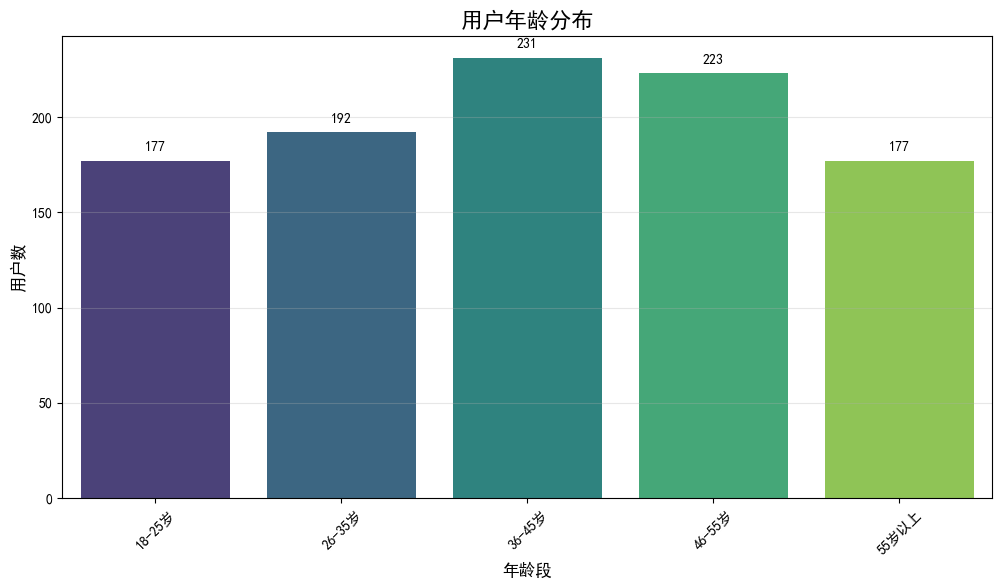

,用户数,占比
Age_Group,,
18-25岁,177,17.7%
26-35岁,192,19.2%
36-45岁,231,23.1%
46-55岁,223,22.3%
55岁以上,177,17.7%


In [3]:
# 年龄分段分析
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ['18-25岁', '26-35岁', '36-45岁', '46-55岁', '55岁以上']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 年龄分布可视化
plt.figure(figsize=(12, 6))
age_dist = df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_dist.index, y=age_dist.values, palette='viridis')
plt.title('用户年龄分布', fontsize=16)
plt.xlabel('年龄段', fontsize=12)
plt.ylabel('用户数', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# 添加数值标签
for i, v in enumerate(age_dist.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.show()

# 年龄分布表格
age_stats = age_dist.to_frame('用户数')
age_stats['占比'] = (age_dist / len(df) * 100).round(1).astype(str) + '%'
age_stats

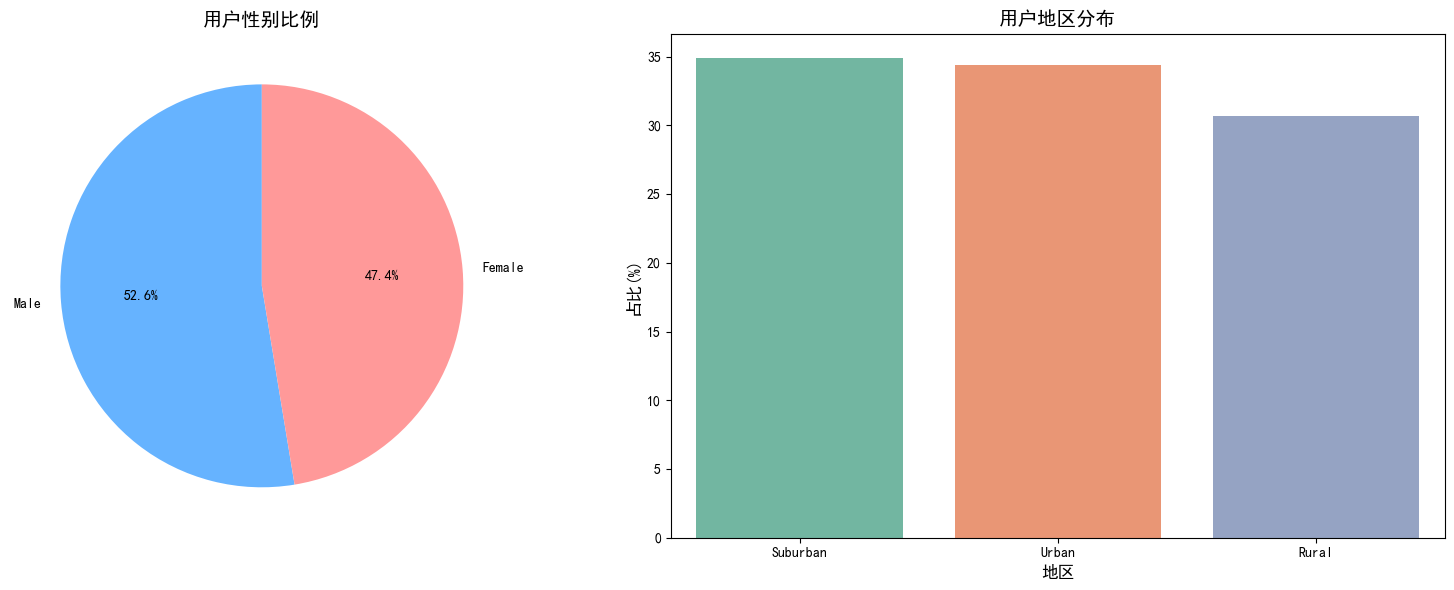

性别比例：男性 52.6%，女性 47.4%

地区分布：


Location
Suburban    34.9
Urban       34.4
Rural       30.7
Name: proportion, dtype: float64

In [4]:
### 1.2 性别与地区分布
# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 性别比例
gender_ratio = df['Gender'].value_counts(normalize=True) * 100
colors = ['#66b3ff', '#ff9999']
ax1.pie(gender_ratio.values, labels=gender_ratio.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('用户性别比例', fontsize=14)

# 地区分布
location_dist = df['Location'].value_counts(normalize=True) * 100
sns.barplot(x=location_dist.index, y=location_dist.values, palette='Set2', ax=ax2)
ax2.set_title('用户地区分布', fontsize=14)
ax2.set_xlabel('地区', fontsize=12)
ax2.set_ylabel('占比(%)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"性别比例：男性 {gender_ratio['Male']:.1f}%，女性 {gender_ratio['Female']:.1f}%")
print(f"\n地区分布：")
location_dist.round(1)

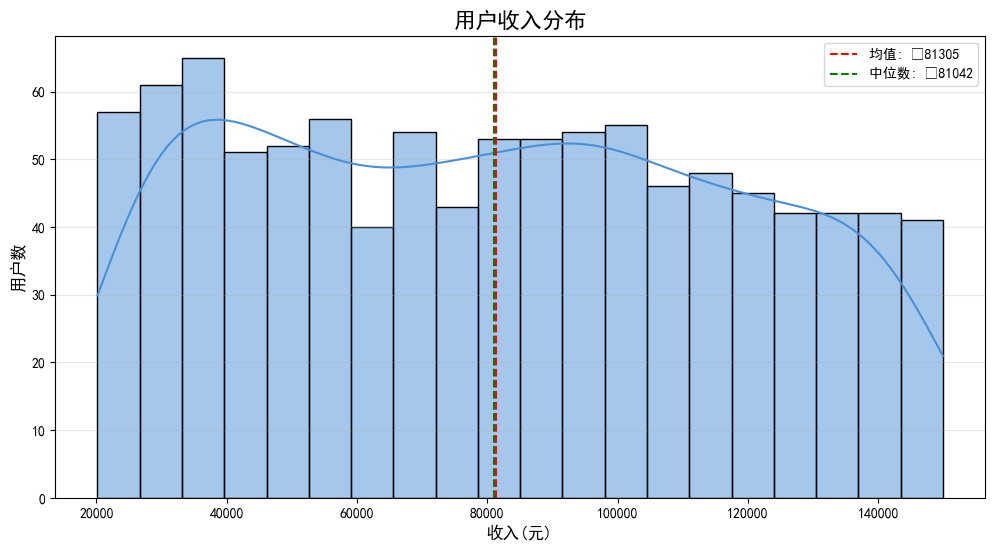

平均收入：¥81305
收入中位数：¥81042
收入标准差：¥37364


In [5]:
### 1.3 收入分布
# 收入统计
income_mean = df['Income'].mean()
income_median = df['Income'].median()
income_std = df['Income'].std()

# 收入分布直方图
plt.figure(figsize=(12, 6))
sns.histplot(df['Income'], bins=20, kde=True, color='#4a90d9')
plt.axvline(income_mean, color='red', linestyle='--', label=f'均值: ¥{income_mean:.0f}')
plt.axvline(income_median, color='green', linestyle='--', label=f'中位数: ¥{income_median:.0f}')
plt.title('用户收入分布', fontsize=16)
plt.xlabel('收入(元)', fontsize=12)
plt.ylabel('用户数', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"平均收入：¥{income_mean:.0f}")
print(f"收入中位数：¥{income_median:.0f}")
print(f"收入标准差：¥{income_std:.0f}")

---

## 2. 用户行为分析

### 2.1 登录行为分析

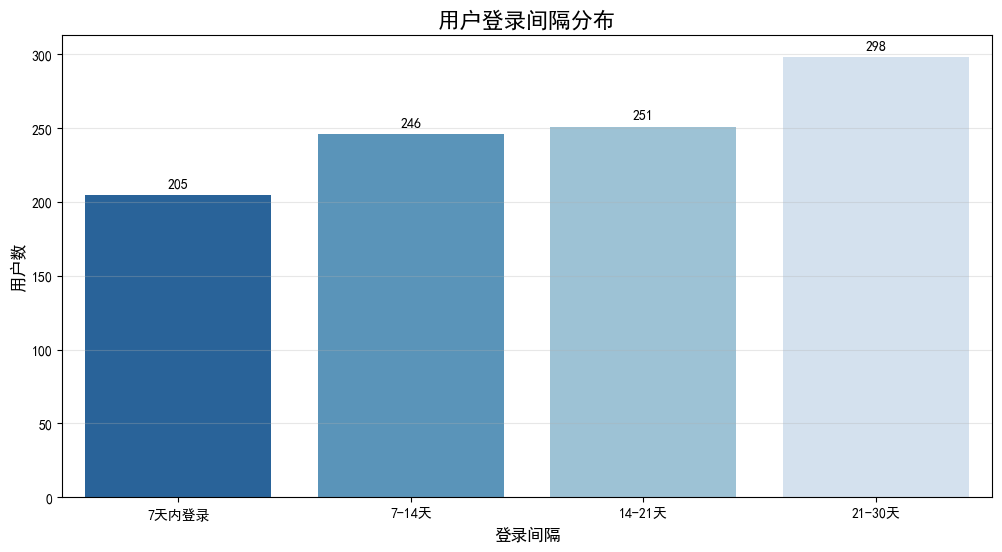

近7天登录用户：205人 (20.5%)


In [6]:
# 登录行为分布
login_bins = [0, 7, 14, 21, 30]
login_labels = ['7天内登录', '7-14天', '14-21天', '21-30天']
df['Login_Frequency_Group'] = pd.cut(df['Last_Login_Days_Ago'], bins=login_bins, labels=login_labels)

# 可视化
plt.figure(figsize=(12, 6))
login_dist = df['Login_Frequency_Group'].value_counts().sort_index()
sns.barplot(x=login_dist.index, y=login_dist.values, palette='Blues_r')
plt.title('用户登录间隔分布', fontsize=16)
plt.xlabel('登录间隔', fontsize=12)
plt.ylabel('用户数', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(login_dist.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

print(f"近7天登录用户：{login_dist['7天内登录']}人 ({login_dist['7天内登录']/len(df)*100:.1f}%)")

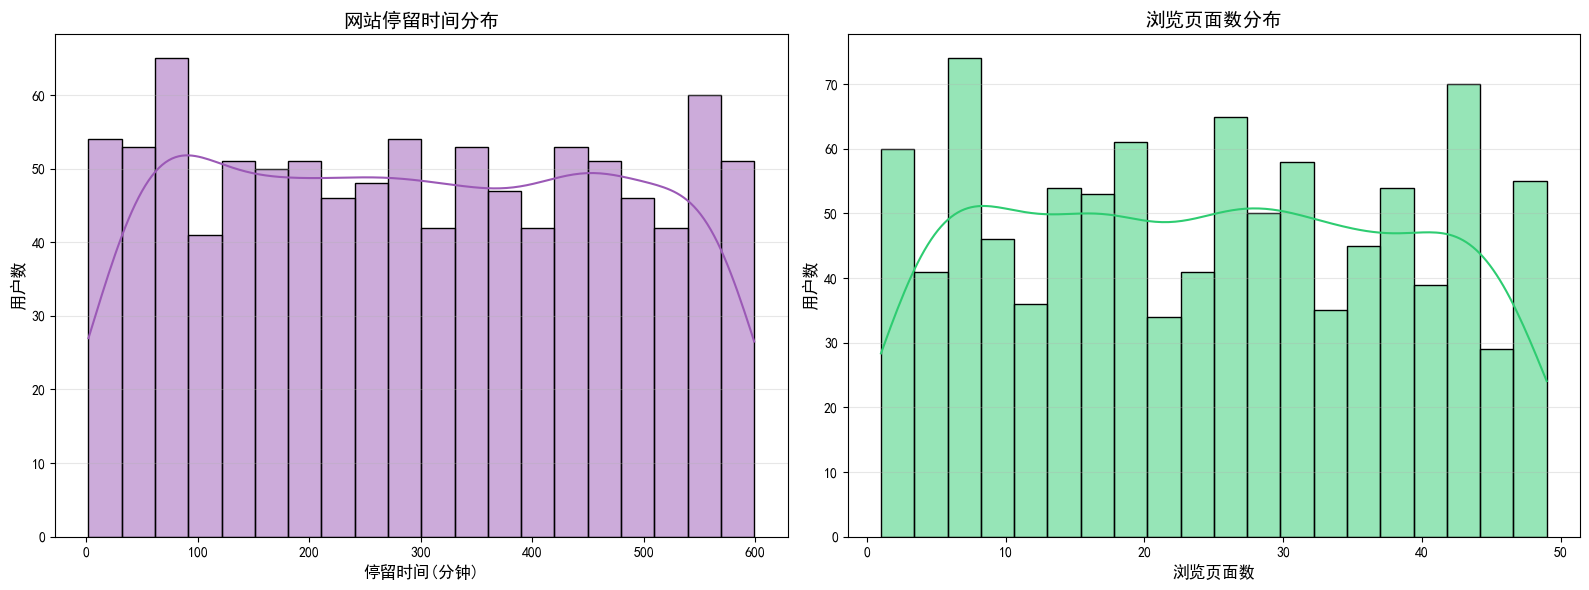

平均停留时间：297 分钟
平均浏览页面：24.4 页


In [7]:
### 2.2 停留时间与浏览深度
# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 停留时间分布
sns.histplot(df['Time_Spent_on_Site_Minutes'], bins=20, kde=True, color='#9b59b6', ax=ax1)
ax1.set_title('网站停留时间分布', fontsize=14)
ax1.set_xlabel('停留时间(分钟)', fontsize=12)
ax1.set_ylabel('用户数', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# 浏览页面数分布
sns.histplot(df['Pages_Viewed'], bins=20, kde=True, color='#2ecc71', ax=ax2)
ax2.set_title('浏览页面数分布', fontsize=14)
ax2.set_xlabel('浏览页面数', fontsize=12)
ax2.set_ylabel('用户数', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"平均停留时间：{df['Time_Spent_on_Site_Minutes'].mean():.0f} 分钟")
print(f"平均浏览页面：{df['Pages_Viewed'].mean():.1f} 页")

---

## 3. 消费行为分析

### 3.1 购买频率与客单价

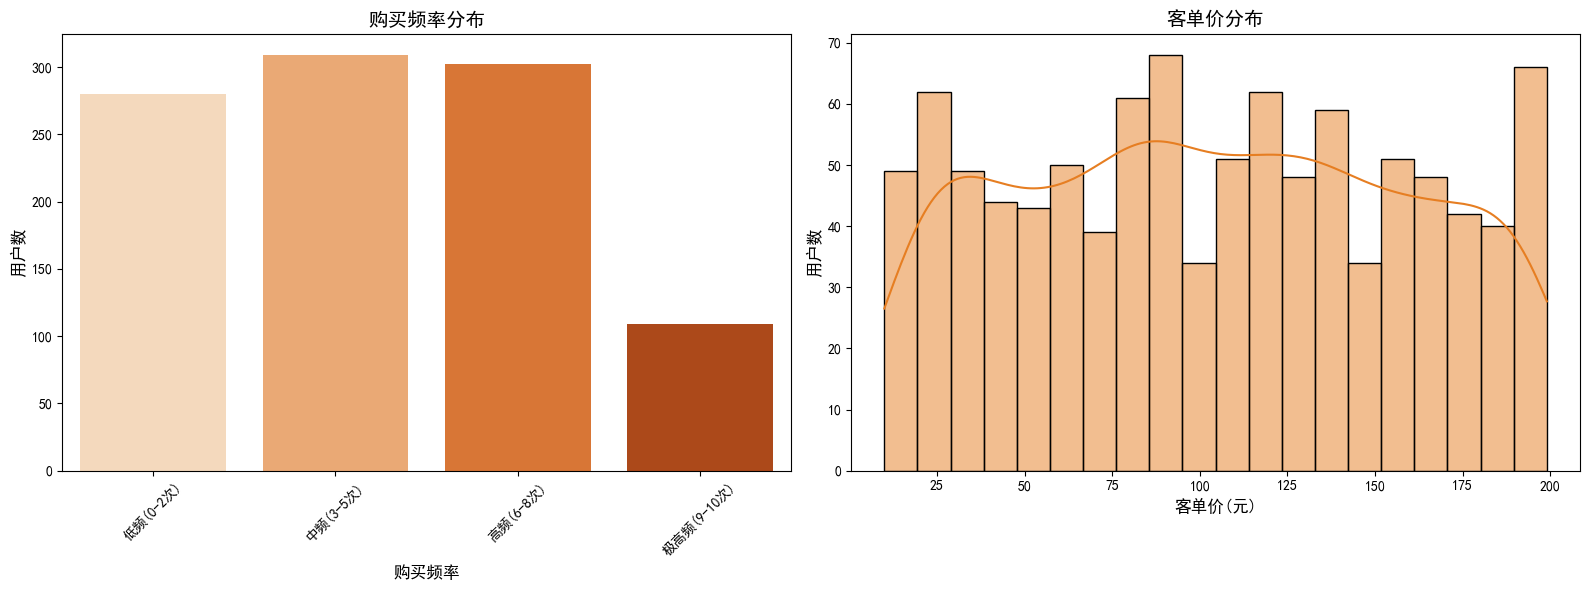

平均客单价：¥104
平均购买频率：4.6 次
中高频用户占比：72.0%


In [8]:
# 购买频率分析
freq_bins = [-1, 2, 5, 8, 10]
freq_labels = ['低频(0-2次)', '中频(3-5次)', '高频(6-8次)', '极高频(9-10次)']
df['Purchase_Freq_Group'] = pd.cut(df['Purchase_Frequency'], bins=freq_bins, labels=freq_labels)

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 购买频率分布
freq_dist = df['Purchase_Freq_Group'].value_counts().sort_index()
sns.barplot(x=freq_dist.index, y=freq_dist.values, palette='Oranges', ax=ax1)
ax1.set_title('购买频率分布', fontsize=14)
ax1.set_xlabel('购买频率', fontsize=12)
ax1.set_ylabel('用户数', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 客单价分布
sns.histplot(df['Average_Order_Value'], bins=20, kde=True, color='#e67e22', ax=ax2)
ax2.set_title('客单价分布', fontsize=14)
ax2.set_xlabel('客单价(元)', fontsize=12)
ax2.set_ylabel('用户数', fontsize=12)

plt.tight_layout()
plt.show()

print(f"平均客单价：¥{df['Average_Order_Value'].mean():.0f}")
print(f"平均购买频率：{df['Purchase_Frequency'].mean():.1f} 次")
print(f"中高频用户占比：{(freq_dist['中频(3-5次)'] + freq_dist['高频(6-8次)'] + freq_dist['极高频(9-10次)']) / len(df) * 100:.1f}%")

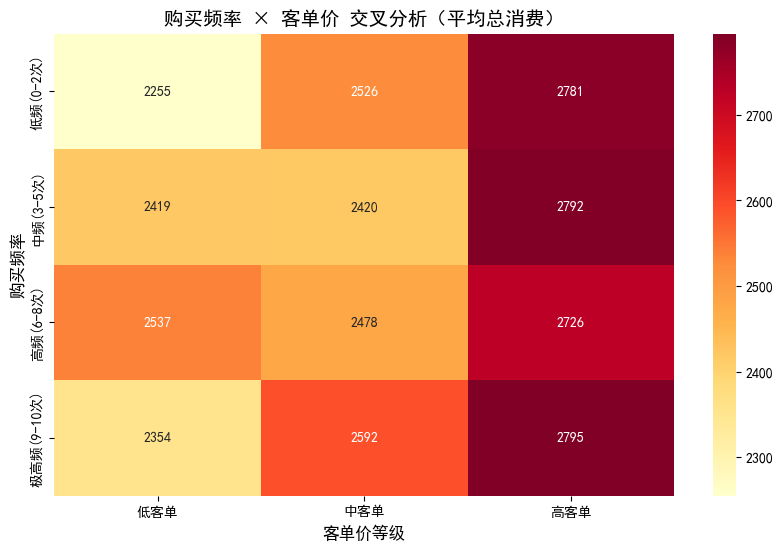

发现：高频+高客单用户贡献最大价值，是重点运营对象


In [9]:
### 3.2 购买频率 × 客单价 交叉分析
# 交叉分析
purchase_aov_matrix = df.groupby(['Purchase_Freq_Group', 'AOV_Level'])['Total_Spending'].mean().unstack()

# 可视化热图
plt.figure(figsize=(10, 6))
sns.heatmap(purchase_aov_matrix.round(0), annot=True, fmt='g', cmap='YlOrRd', cbar=True)
plt.title('购买频率 × 客单价 交叉分析（平均总消费）', fontsize=14)
plt.xlabel('客单价等级', fontsize=12)
plt.ylabel('购买频率', fontsize=12)
plt.show()

print("发现：高频+高客单用户贡献最大价值，是重点运营对象")

---

## 4. 用户分群分析（RFM + K-Means）

### 4.1 K-Means聚类

In [10]:
# 构建RFM特征
rfm = df[['Last_Login_Days_Ago', 'Purchase_Frequency', 'Total_Spending']].copy()
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 数据标准化
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# K-Means聚类
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 分析各簇特征
cluster_profile = df.groupby('Cluster').agg({
    'Last_Login_Days_Ago': 'mean',
    'Purchase_Frequency': 'mean',
    'Total_Spending': 'mean',
    'Average_Order_Value': 'mean',
    'User_ID': 'count'
}).round(1)
cluster_profile.columns = ['平均登录间隔(天)', '平均购买频次', '平均总消费', '平均客单价', '用户数']

# 为各簇命名
cluster_names = {}
for cluster_id in range(4):
    cluster_data = df[df['Cluster'] == cluster_id]
    r_score = cluster_data['Last_Login_Days_Ago'].mean()
    f_score = cluster_data['Purchase_Frequency'].mean()
    m_score = cluster_data['Total_Spending'].mean()
    
    if f_score > df['Purchase_Frequency'].median() and m_score > df['Total_Spending'].median():
        cluster_names[cluster_id] = '高价值活跃用户'
    elif f_score > df['Purchase_Frequency'].median():
        cluster_names[cluster_id] = '频次型用户'
    elif m_score > df['Total_Spending'].median():
        cluster_names[cluster_id] = '高客单用户'
    else:
        cluster_names[cluster_id] = '低价值用户'

df['Cluster_Name'] = df['Cluster'].map(cluster_names)
cluster_profile['簇名称'] = cluster_profile.index.map(cluster_names)
cluster_profile

,平均登录间隔(天),平均购买频次,平均总消费,平均客单价,用户数,簇名称
Cluster,,,,,,
0,22.8,6.9,2030.5,102.8,259,频次型用户
1,12.2,2.3,1317.2,98.6,265,低价值用户
2,19.5,2.5,3920.8,110.4,232,高客单用户
3,7.9,6.7,3149.0,105.1,244,高价值活跃用户


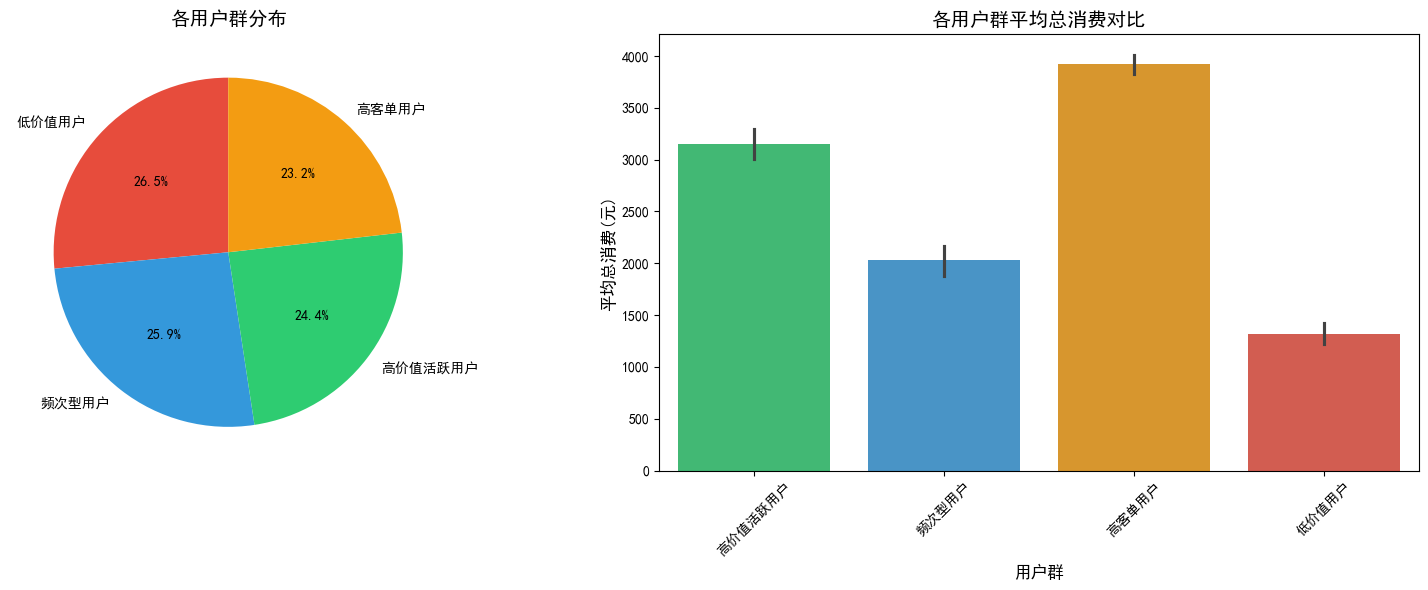

In [11]:
# 可视化分群结果
# 创建颜色映射
cluster_colors = {
    '高价值活跃用户': '#2ecc71',
    '频次型用户': '#3498db',
    '高客单用户': '#f39c12',
    '低价值用户': '#e74c3c'
}

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 各簇用户数量分布
cluster_counts = df['Cluster_Name'].value_counts()
ax1.pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%',
        colors=[cluster_colors[name] for name in cluster_counts.index], startangle=90)
ax1.set_title('各用户群分布', fontsize=14)

# 各簇消费对比
sns.barplot(x='Cluster_Name', y='Total_Spending', data=df, palette=cluster_colors, ax=ax2)
ax2.set_title('各用户群平均总消费对比', fontsize=14)
ax2.set_xlabel('用户群', fontsize=12)
ax2.set_ylabel('平均总消费(元)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.2 分群运营建议

| 用户群 | 特征 | 运营策略 |
|--------|------|---------|
| **高价值活跃用户** | 高频登录+高购买+高消费 | VIP服务、专属优惠、优先体验新品 |
| **频次型用户** | 高购买频次但客单价一般 | 提升客单价（满减、套餐推荐） |
| **高客单用户** | 低频次但高客单价 | 增加购买频次（定期提醒、订阅制） |
| **低价值用户** | 低频次+低消费 | 激活策略（新人优惠、限时折扣） |

---

## 5. 兴趣偏好分析

### 5.1 兴趣标签分布

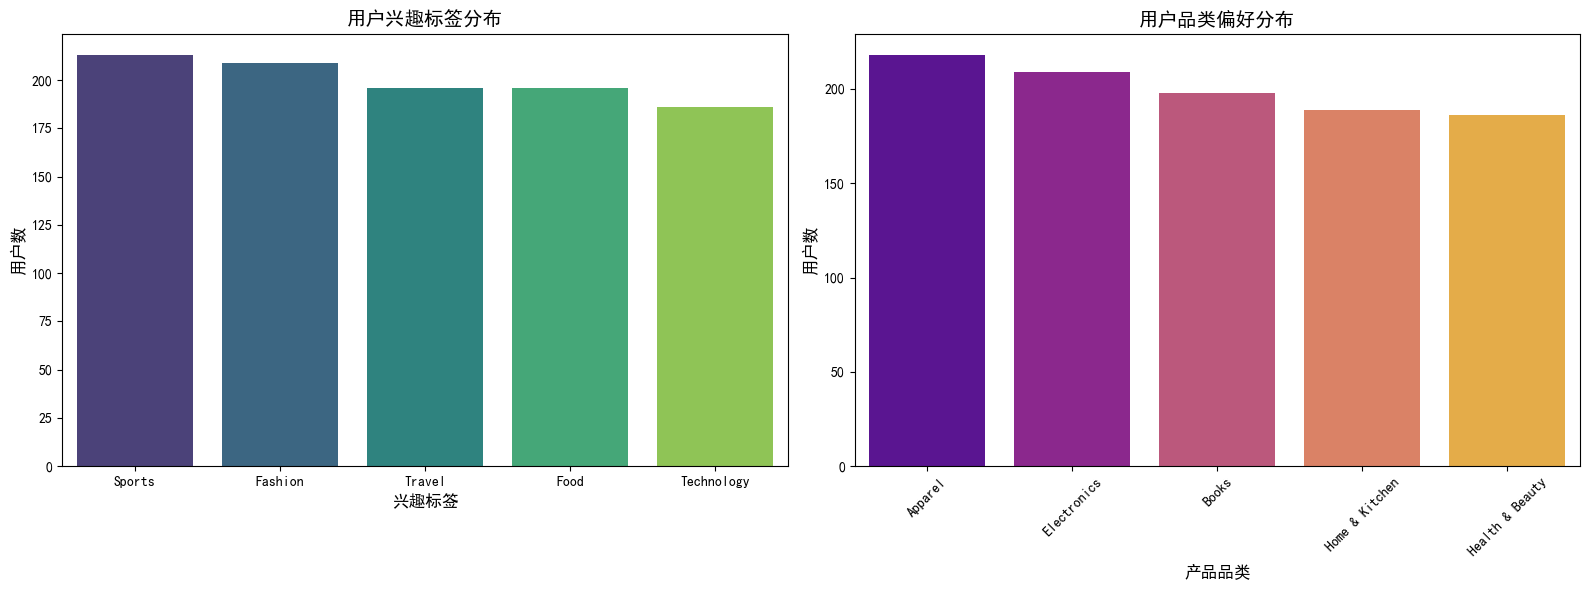

In [12]:
# 兴趣分布
interest_dist = df['Interests'].value_counts()

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 兴趣标签分布
sns.barplot(x=interest_dist.index, y=interest_dist.values, palette='viridis', ax=ax1)
ax1.set_title('用户兴趣标签分布', fontsize=14)
ax1.set_xlabel('兴趣标签', fontsize=12)
ax1.set_ylabel('用户数', fontsize=12)

# 品类偏好分布
category_dist = df['Product_Category_Preference'].value_counts()
sns.barplot(x=category_dist.index, y=category_dist.values, palette='plasma', ax=ax2)
ax2.set_title('用户品类偏好分布', fontsize=14)
ax2.set_xlabel('产品品类', fontsize=12)
ax2.set_ylabel('用户数', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

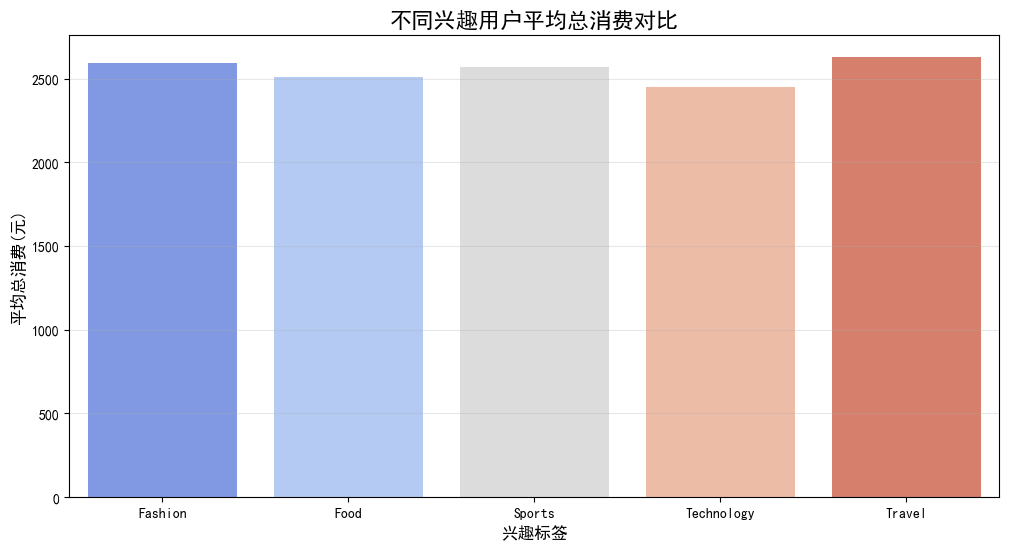

,平均总消费,平均购买频次,平均客单价,平均停留时间
Interests,,,,
Fashion,2593.7,4.4,103.3,314.4
Food,2511.8,4.7,111.3,282.8
Sports,2569.8,4.6,103.3,306.3
Technology,2452.2,5.1,102.4,274.9
Travel,2628.0,4.4,100.0,305.3


In [13]:
### 5.2 兴趣与消费行为关系
# 不同兴趣用户的消费特征
interest_spending = df.groupby('Interests').agg({
    'Total_Spending': 'mean',
    'Purchase_Frequency': 'mean',
    'Average_Order_Value': 'mean',
    'Time_Spent_on_Site_Minutes': 'mean'
}).round(1)
interest_spending.columns = ['平均总消费', '平均购买频次', '平均客单价', '平均停留时间']

# 可视化
plt.figure(figsize=(12, 6))
sns.barplot(x=interest_spending.index, y='平均总消费', data=interest_spending, palette='coolwarm')
plt.title('不同兴趣用户平均总消费对比', fontsize=16)
plt.xlabel('兴趣标签', fontsize=12)
plt.ylabel('平均总消费(元)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

interest_spending

---

## 6. 用户活跃度分析

### 6.1 活跃度等级分布

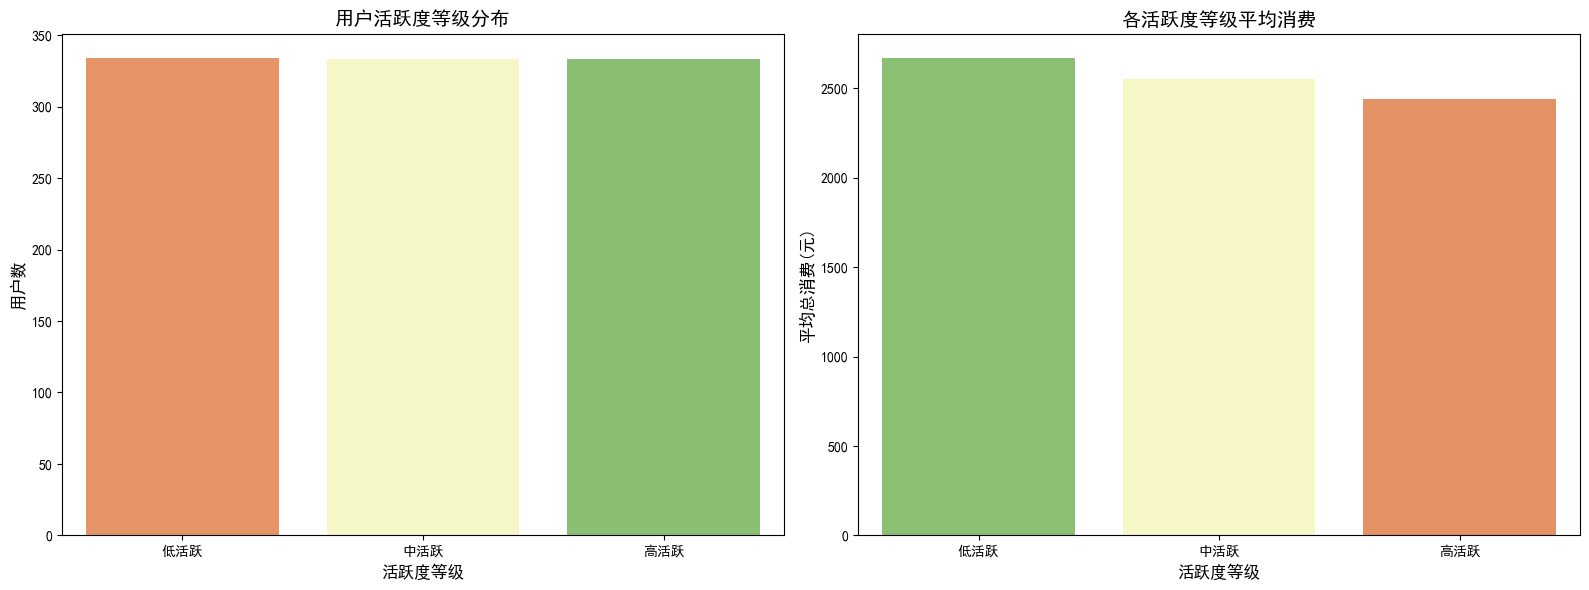

总体邮件订阅率：50.7%

各活跃度等级订阅率：


Activity_Level
低活跃    51.796407
中活跃    48.648649
高活跃    51.651652
Name: Newsletter_Subscription, dtype: float64

In [14]:
# 活跃度分布
activity_dist = df['Activity_Level'].value_counts()

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 活跃度等级分布
sns.barplot(x=activity_dist.index, y=activity_dist.values, palette='RdYlGn', ax=ax1)
ax1.set_title('用户活跃度等级分布', fontsize=14)
ax1.set_xlabel('活跃度等级', fontsize=12)
ax1.set_ylabel('用户数', fontsize=12)

# 活跃度与消费关系
activity_spending = df.groupby('Activity_Level')['Total_Spending'].mean()
sns.barplot(x=activity_spending.index, y=activity_spending.values, palette='RdYlGn_r', ax=ax2)
ax2.set_title('各活跃度等级平均消费', fontsize=14)
ax2.set_xlabel('活跃度等级', fontsize=12)
ax2.set_ylabel('平均总消费(元)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"总体邮件订阅率：{df['Newsletter_Subscription'].mean()*100:.1f}%")
print(f"\n各活跃度等级订阅率：")
df.groupby('Activity_Level')['Newsletter_Subscription'].mean() * 100

流失风险用户数量：179人 (17.9%)
平均历史消费：¥2703
平均购买频次：5.0次
预计可挽回收入：¥483838+


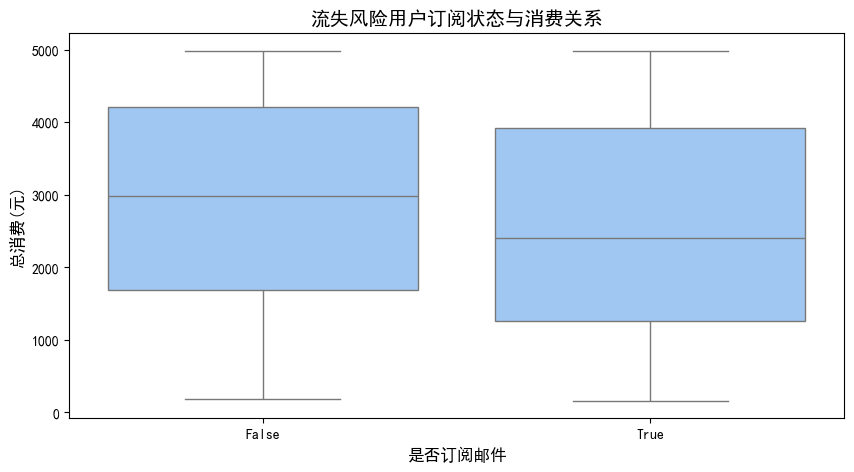


建议：对这179名用户立即启动召回活动（专属优惠、个性化推荐邮件）


In [15]:
### 6.2 流失风险用户识别
# 识别流失风险用户（25天+未登录）
churn_risk = df[df['Last_Login_Days_Ago'] >= 25]

print(f"流失风险用户数量：{len(churn_risk)}人 ({len(churn_risk)/len(df)*100:.1f}%)")
print(f"平均历史消费：¥{churn_risk['Total_Spending'].mean():.0f}")
print(f"平均购买频次：{churn_risk['Purchase_Frequency'].mean():.1f}次")
print(f"预计可挽回收入：¥{(churn_risk['Total_Spending'].mean() * len(churn_risk)):.0f}+")

# 可视化流失风险用户特征
plt.figure(figsize=(10, 5))
sns.boxplot(x='Newsletter_Subscription', y='Total_Spending', data=churn_risk)
plt.title('流失风险用户订阅状态与消费关系', fontsize=14)
plt.xlabel('是否订阅邮件', fontsize=12)
plt.ylabel('总消费(元)', fontsize=12)
plt.show()

print("\n建议：对这179名用户立即启动召回活动（专属优惠、个性化推荐邮件）")

---

## 7. 相关性分析

### 7.1 关键指标相关性矩阵

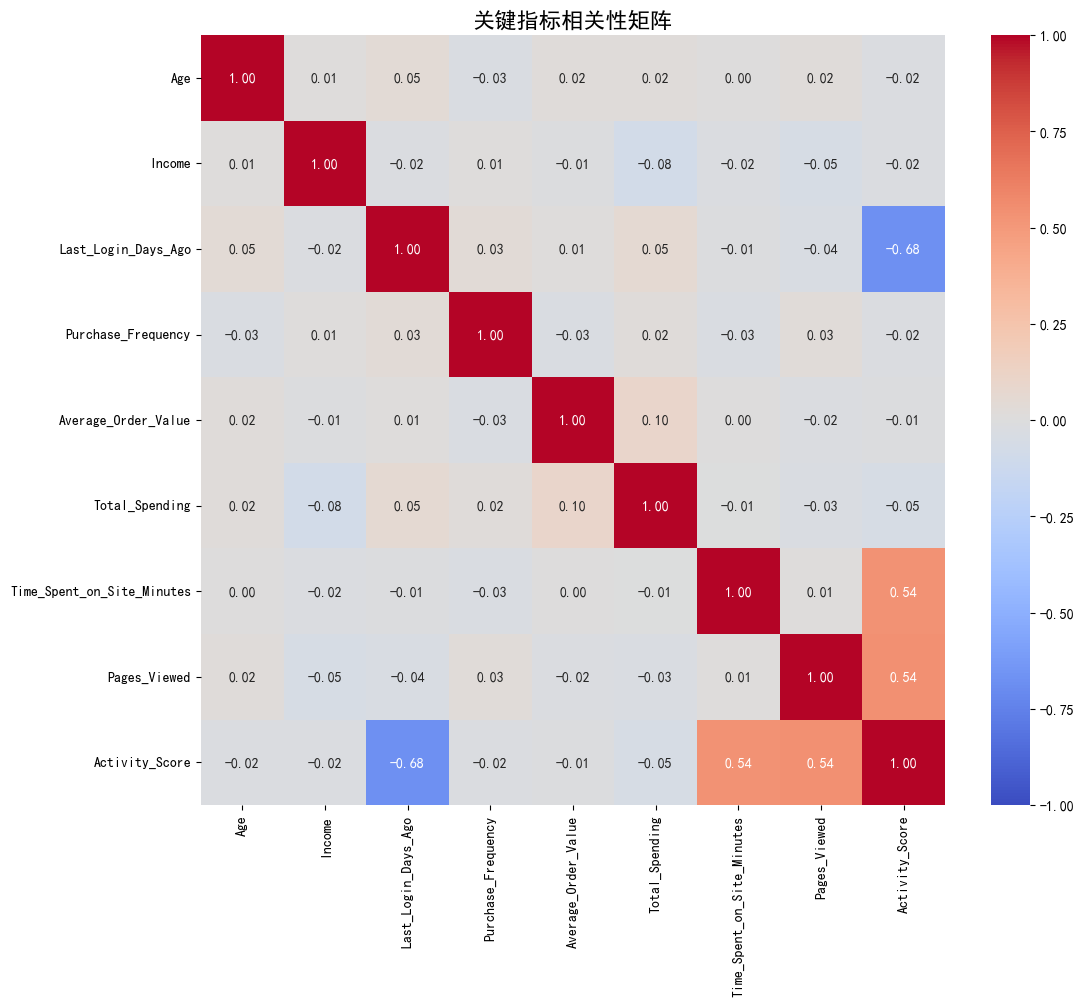

In [16]:
# 选择数值变量
numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                'Pages_Viewed', 'Activity_Score']

# 计算相关性矩阵
corr_matrix = df[numeric_cols].corr()

# 可视化相关性热图
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('关键指标相关性矩阵', fontsize=16)
plt.show()

In [17]:
# 提取强相关性(|r| > 0.3)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            strong_corr.append({
                '变量1': corr_matrix.columns[i],
                '变量2': corr_matrix.columns[j],
                '相关系数': corr_val.round(2)
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('相关系数', key=abs, ascending=False)
strong_corr_df

,变量1,变量2,相关系数
0,Last_Login_Days_Ago,Activity_Score,-0.68
1,Time_Spent_on_Site_Minutes,Activity_Score,0.54
2,Pages_Viewed,Activity_Score,0.54


### 7.2 关键发现

| 指标对 | 相关系数 | 业务解读 |
|--------|---------|---------|
| 收入 vs 总消费 | -0.085 | **几乎无关**：收入高低不直接决定消费金额 |
| 停留时间 vs 总消费 | -0.006 | **无关**：停留时间长短不影响消费 |
| 登录间隔 vs 购买频率 | 0.033 | **几乎无关**：登录频率不直接转化为购买 |

**重要洞察**：
1. 传统电商假设"收入越高消费越高"在本平台不成立
2. "停留时间越长消费越多"也不成立
3. 这说明平台的转化机制可能存在问题，需要优化从浏览到购买的转化路径

---

## 8. 高价值用户画像（TOP20%）

### 8.1 高价值用户 vs 其他用户对比

In [18]:
# 定义高价值用户
threshold = df['Total_Spending'].quantile(0.8)
high_value = df[df['Total_Spending'] >= threshold]
avg_users = df[df['Total_Spending'] < threshold]

# 对比分析
comparison = pd.DataFrame({
    '高价值用户(TOP20%)': high_value[['Age', 'Income', 'Purchase_Frequency', 
                                      'Average_Order_Value', 'Time_Spent_on_Site_Minutes',
                                      'Pages_Viewed']].mean().round(1),
    '其他用户': avg_users[['Age', 'Income', 'Purchase_Frequency', 
                           'Average_Order_Value', 'Time_Spent_on_Site_Minutes',
                           'Pages_Viewed']].mean().round(1)
})

comparison['差异'] = comparison['高价值用户(TOP20%)'] - comparison['其他用户']
comparison

,高价值用户(TOP20%),其他用户,差异
Age,41.8,40.8,1.0
Income,76526.2,82506.8,-5980.6
Purchase_Frequency,4.8,4.6,0.2
Average_Order_Value,110.9,102.3,8.6
Time_Spent_on_Site_Minutes,281.2,301.4,-20.2
Pages_Viewed,23.3,24.7,-1.4


<Figure size 1200x600 with 0 Axes>

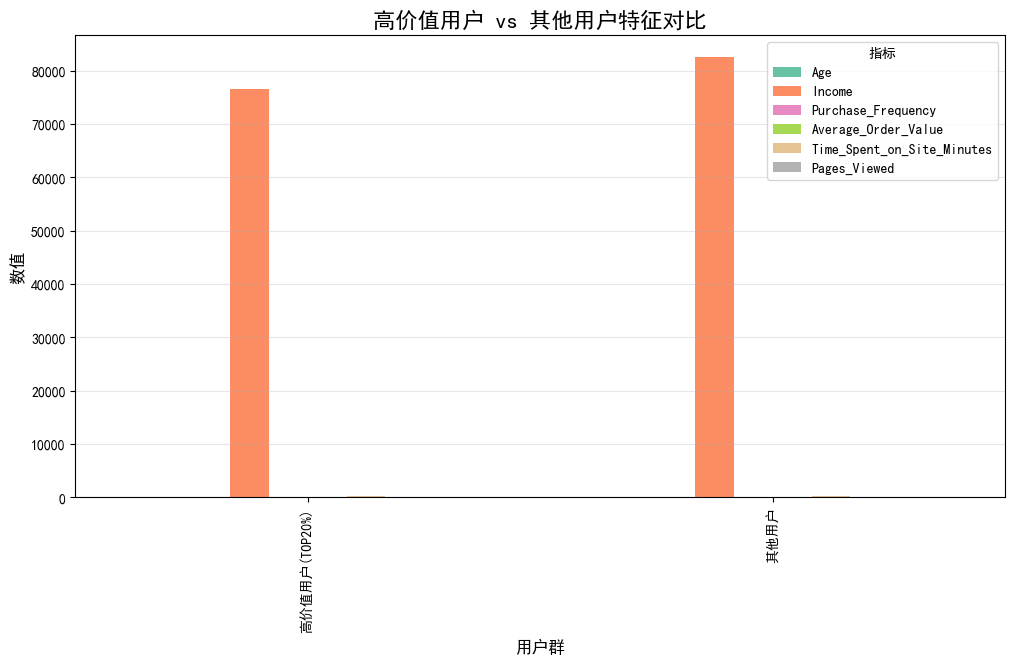

In [19]:
# 可视化对比
comparison_plot = comparison[['高价值用户(TOP20%)', '其他用户']].T

plt.figure(figsize=(12, 6))
comparison_plot.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('高价值用户 vs 其他用户特征对比', fontsize=16)
plt.xlabel('用户群', fontsize=12)
plt.ylabel('数值', fontsize=12)
plt.legend(title='指标')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 8.2 关键发现与运营建议

**关键发现**：
1. 高价值用户**收入反而更低**，说明消费意愿比消费能力更重要
2. 高价值用户**停留时间更短**，说明他们目标明确，购买决策快
3. 高价值用户**客单价更高**（¥111 vs ¥102），这是区分高低价值用户的关键指标

**运营建议**：
1. **重点运营兴趣标签**：Fashion 和 Sports
2. **重点推荐品类**：Apparel（服装）和 Home & Kitchen
3. **重点投放地区**：城市地区
4. **邮件营销策略**：高价值用户订阅率过半，应加强个性化邮件营销
5. **用户体验优化**：高价值用户停留时间短但消费高，应优化购买路径，减少决策时间